<a href="https://colab.research.google.com/github/Thisyath/Computer-Vision-Practice/blob/main/1_Representasi_Citra_Digital/Representasi_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Image I/O dengan OpenCV

- cv2.imread() membaca file gambar dalam format BGR.

- Validasi memastikan file benar-benar terbaca.

- cv2.cvtColor() mengubah BGR ke RGB agar warna tampil benar di Matplotlib.

- plt.imshow() menampilkan citra.

- cv2.imwrite() menyimpan citra hasil ke folder output.

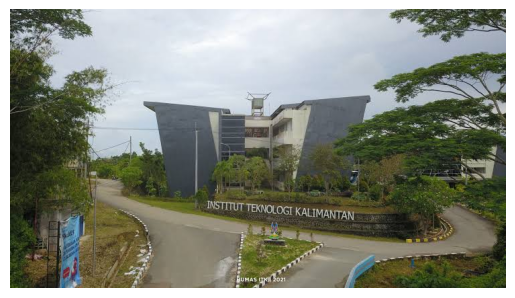

False

In [9]:
import cv2
import matplotlib.pyplot as plt

# 1. Baca citra dalam format BGR
img_bgr = cv2.imread("/content/drive/MyDrive/S5_Komputer_Vision/Data/Input/kampus.jpg")

# 2. Validasi file terbaca
if img_bgr is None:
    raise FileNotFoundError("File citra tidak ditemukan")

# 3. Konversi BGR ke RGB agar benar saat ditampilkan Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 4. Tampilkan citra
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# 5. Simpan citra hasil
cv2.imwrite("output/kampus_copy.jpg", img_bgr)

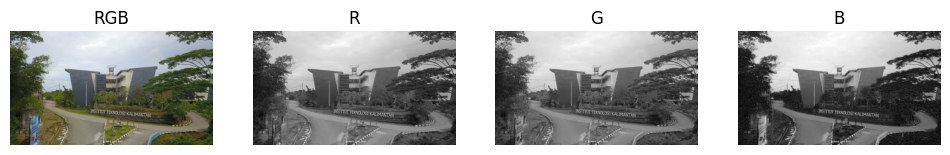

In [10]:
# img_bgr berasal dari cv2.imread()
b, g, r = cv2.split(img_bgr)

# Gabungkan kembali dalam urutan BGR
img_bgr_merge = cv2.merge([b, g, r])

# Konversi ke RGB untuk visualisasi
img_rgb = cv2.merge([r, g, b])

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(img_rgb); ax[0].set_title("RGB")
ax[1].imshow(r, cmap="gray"); ax[1].set_title("R")
ax[2].imshow(g, cmap="gray"); ax[2].set_title("G")
ax[3].imshow(b, cmap="gray"); ax[3].set_title("B")

for a in ax:
    a.axis("off")

plt.show()


Ukuran BGR        : (415, 739, 3)
Ukuran grayscale  : (415, 739)
Tipe data         : uint8
Min - Max         : 0 255


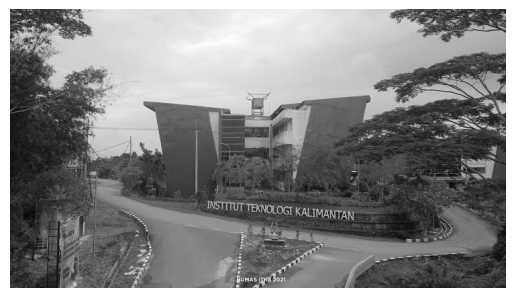

In [11]:
# Konversi BGR ke grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Ukuran BGR        :", img_bgr.shape)        # H x W x 3
print("Ukuran grayscale  :", gray.shape)           # H x W
print("Tipe data         :", gray.dtype)
print("Min - Max         :", gray.min(), gray.max())

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()


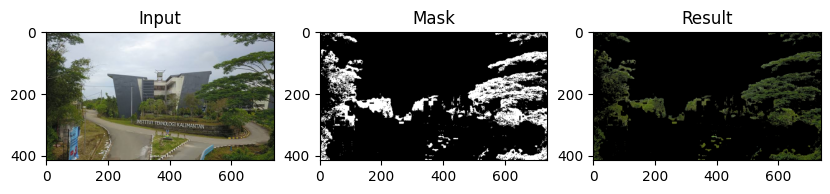

In [12]:
import numpy as np

hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Contoh rentang warna hijau, perlu disesuaikan dengan data
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)
result = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Result")

plt.show()


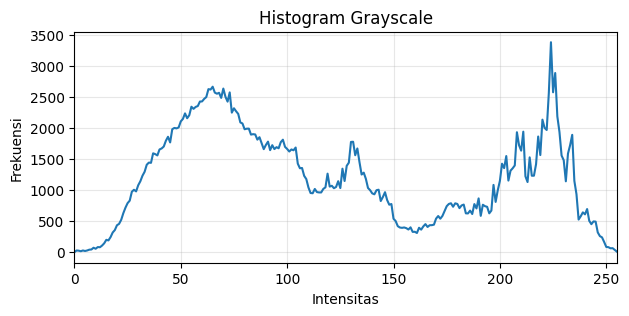

In [13]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Histogram grayscale: 256 bin, rentang 0–256
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(7, 3))
plt.plot(hist)
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")
plt.xlim([0, 255])
plt.grid(True, alpha=0.3)
plt.show()


Ukuran awal : (415, 739, 3)
Ukuran baru : (208, 370, 3)


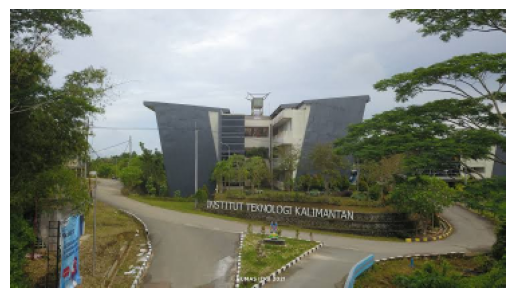

In [14]:
# Resize dengan ukuran eksplisit: width=300, height=200
resized = cv2.resize(img_bgr, (300, 200), interpolation=cv2.INTER_LINEAR)

# Resize proporsional 50 persen
scale = 0.5
small = cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

print("Ukuran awal :", img_bgr.shape)
print("Ukuran baru :", small.shape)

plt.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Ukuran awal : (415, 739, 3)
Ukuran baru : (208, 370, 3)


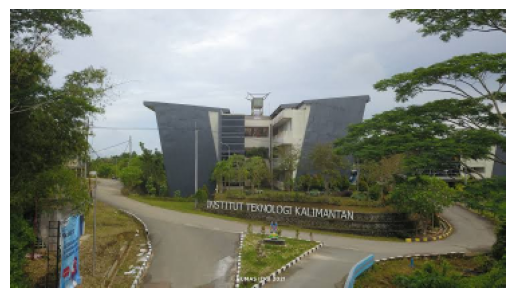

In [15]:
# Resize dengan ukuran eksplisit: width=300, height=200
resized = cv2.resize(img_bgr, (300, 200), interpolation=cv2.INTER_LINEAR)

# Resize proporsional 50 persen
scale = 0.5
small = cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

print("Ukuran awal :", img_bgr.shape)
print("Ukuran baru :", small.shape)

plt.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
